# Imports

In [1]:
import os
import warnings
from collections import defaultdict
import datetime

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import pickle

import torch

import Levenshtein
from pdbfixer import PDBFixer
from openmm.app import PDBFile

import kit
import kit.globals as G
from kit.log import log_info
from kit.data import DD, Split, file_to_str, str_to_file
from kit.path import join
from kit.bioinf.pdb import download_structure, pdb_to_seqs, includes_dna, check_xray, get_protein_name_organism
from kit.bioinf.proteins import Protein, ProteinType
from kit.bioinf.proteins.eval import calc_sequence_recovery
from kit.bioinf.proteins.display import print_seq
from kit.bioinf.proteins.similar import get_similar_proteins
from kit.bioinf.immuno.mhc_1 import Mhc1Predictor
from kit.bioinf.immuno.utils import get_mhc_1_setup_hash
from kit.bioinf.utils import get_seq_hash, check_same_sequences
from kit.bioinf.utils.filter import filter_pdbs

import CAPE
from CAPE.MPNN.model import CapeMPNN
from CAPE.MPNN.overwrite import tied_featurize
from CAPE.MPNN.data.utils import get_data_loaders_pdb, get_structure_data_sets, OMIT_AAs_NP, BIAS_AAs_NP
from CAPE.MPNN.ProteinMPNN.training.utils import StructureLoader
from CAPE.Eval.MPNN.design import Design, BestTrial
from CAPE.Eval.MPNN.plots import set_colors, set_markers, get_palette, \
    plot_trade_off, plot_hyp_search, plot_specific, plot_infos, plot_rank_dist
from CAPE.Eval.MPNN.db import CapeMpnnDB
from CAPE.Eval.MPNN.utils import sources_to_model_ids, download_specific_protein, send_to_pdb, \
    c_avg_vis_mhc_1_v_g, c_avg_vis_mhc_1_pc_v_g, c_avg_rec_v_g, c_avg_tm_v_s, \
    c_avg_vis_mhc_1_v_s, c_avg_tm_t_s, c_avg_vis_mhc_1_t_s

from CAPE.Eval.MPNN.general import generate_general
from CAPE.Eval.MPNN.specific import call_mpnn

from kit.loch.oo import Loch

In [2]:
# Enable LaTeX text rendering
plt.rcParams['text.usetex'] = False

# To ignore all future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")

# Startup

In [3]:
args, args_unknown = kit.init('CAPE', 'CAPE-MPNN', create_job=False, arg_string=None)

Startup with args: Namespace(task='', job='AUTO', domain='d', env='py', device='cuda', debug=None, project_path=None, loch_path=None) ENV.PROJECT: '/media/thoth/FILES/study/ed/PhD/projects/cape'
2025-03-11 17:53:06:  WARNING: TASK NOT SPECIFIED
2025-03-11 17:53:06:  Start CAPE-None-None on py using cuda
2025-03-11 17:53:06:  G.ENV
2025-03-11 17:53:06:  PROJECT   ... /media/thoth/FILES/study/ed/PhD/projects/cape
2025-03-11 17:53:06:  ID        ... py
2025-03-11 17:53:06:  KIT       ... /media/thoth/FILES/study/ed/PhD/projects/cape/artefacts/kit
2025-03-11 17:53:06:  RAW       ... /media/thoth/FILES/study/ed/PhD/projects/cape/data/raw
2025-03-11 17:53:06:  INPUT     ... /media/thoth/FILES/study/ed/PhD/projects/cape/data/input
2025-03-11 17:53:06:  CONFIG    ... /media/thoth/FILES/study/ed/PhD/projects/cape/configs/CAPE-MPNN
2025-03-11 17:53:06:  ARTEFACTS ... /media/thoth/FILES/study/ed/PhD/projects/cape/artefacts/CAPE-MPNN
2025-03-11 17:53:06:  ARTEFACTS_SHARED... /media/thoth/FILES/stu

# Configs

## Design

In [4]:
kit.DEVICE = 'cpu'

In [5]:
SPECIFIC_TRIALS = [1, 2, 3]  # every specific protein gets designed 3 times
BEST_TRIAL = BestTrial.TM_NINETY_MIN_VIS  # specify the test trial of those as first, the one above a TM score and then with minimal visibility
BEST_TRIAL.mhc_1_key = None  # set below after initialization of predictor

EPOCHS = [2, 10, 20]

In [6]:
ckpt_ids_selected = ["e32b8ed0:epoch_10", "e32b8ed0:epoch_20", "458340e4:epoch_10", "458340e4:epoch_20"]

## Individual

In [7]:
person_mhc_1_alleles = "HLA-A*02:01+HLA-A*24:02+HLA-B*07:02+HLA-B*39:01+HLA-C*07:01+HLA-C*16:01"
immuno_setup = {"mhc_1": person_mhc_1_alleles}
mhc_1_setup_hash = get_mhc_1_setup_hash(immuno_setup['mhc_1'])

## Protein Data

In [8]:
MAX_PROTEIN_LENGTH = 2000

### General Protein Data

In [9]:
RESCUT = 3.5
DEBUG = False
MULTITHREADING = False
BATCH_SIZE = 2000
NUM_EXAMPLES_PER_EPOCH = 1000000
temperature = 0.000001

### Specific Protein Data

In [10]:
SPECIFIC_MANUAL = ['1M40', '1SQ3', '1UBQ', '2QMT', '4KW4']
SPECIFIC_VAL = ['1B9K', '1OA4', '1QWK', '1TJE', '1XGD', '4RQG']
SPECIFIC_TEST = ['1A3H', '1P3C', '1PGS', '1QKD', '1S5T', '1X0M', '2BK8', '3O6A', '3TIP', '3WOY']

IDENTIFY_SPECIFIC = True if (SPECIFIC_VAL is None or SPECIFIC_TEST is None) else False

In [11]:
MIN_SPECIFIC_CHAIN_LENGTH = 51
N_SPECIFIC = {
    Split.VAL: 6,
    Split.TEST: 15 - len(SPECIFIC_MANUAL)  # show in total 15 proteins in the figures
}
CANDIDATE_MAX_UNMODELLED = 5
CANDIDATE_EXCLUDE_SMALL_MOLECULES = True

In [12]:
SIMILAR_MIN_PROTEINS_CNT = 3
SIMILAR_MAX_PROTEINS_CNT = 10

SIMILAR_MAX_SCORE = 0.99
SIMILAR_MIN_SCORE = 0.1
SIMILAR_MIN_TM_SCORE = 0.9
SIMILAR_MAX_LENGTH_DIFF = 0.1

In [13]:
KEEP_CHAINS = {}

## Graphics

In [14]:
set_colors(
    "blue",  # general checkpoints
    "red",   # ProteinMPNN
    {        # CAPE-MPNN
        "e32b8ed0": "orange", 
        "458340e4": "pink"
    }, 
    "red",    # 
    "green",  # templates
)
set_markers(
    '.',     # general checkpoints
    'o',     # ProteinMPNN
    {        # CAPE-MPNN epoch dependent
        2: 'v', 
        10: 's', 
        20: 'p'
    }
)

In [15]:
DESTRESS_INFOS_TO_PLOT = {
    # info: axis label (info_name, delta, relative, normalize, hline, y_scale, alpha, good, ylim, height_ratios)
    'dssp': ('dssp edit dist', True, False, False, None, 'linear', 0.005, -1, None, None),
    'rosetta_total': ('rosetta total', False, False, True, None, ['symlog', 'linear'], 0.01, 0, [(1., 10000), (-4., 1.)], [3, 5]), 
    'hydrophobic_fitness': ('delta hydrophobic fitness', True, False, False, 0., 'linear', 0.01, -1, None, None), 
    'packing_density': ('packing density', False, False, False, None, 'linear', 0.01, 1, None, None),
    'aggrescan3d_avg': ('delta aggrescan3d avg', True, False, False, 0., 'linear', 0.01, -1, None, None), 
    'aggrescan3d_max': ('delta aggrescan3d max', True, False, False, 0., 'linear', 0.01, -1, None, None), 
    'isoelectric_point': ('isoelectric point', False, False, False, None, 'linear', 0.01, 0, None, None), 
}

In [16]:
RENAME_SOURCE_IDS = {'v_48_020': 'ProteinMPNN', 'data': 'template'}

## System

In [17]:
RELOAD_BATCHES = False
SAVE_FIGURES = False
FIX_PDBs = True
MIN_AA_DIVERSITY = 10
MAX_AA_CONTENT = 0.5

In [18]:
PDB_SERVER = r'https://files.rcsb.org'

In [19]:
CAPE_MPNN_MODELS_DIR_PATH = os.path.join(G.ENV.ARTEFACTS, "models")
FASTA_OUTPUT_PATH = join(G.ENV.ARTEFACTS, 'outputs', 'fasta')


LOCH_PATH = join(G.ENV.ARTEFACTS, 'loch')
PDB_DIR_PATH = join(G.ENV.PROJECT, 'data', 'input', 'PDBs')
COLABFOLD_PATH = join(G.PROJECT_ENV.ARTEFACTS, 'colabfold')
SIMILAR_PROTEINS_PATH = join(G.ENV.ARTEFACTS, 'eval', 'similar_PDBs')

GENERAL_DATA_DIR_PATH = os.path.join(G.ENV.INPUT, "CAPE-MPNN", "pdb_2021aug02")
GENERAL_EVAL_DIR_PATH = join(G.ENV.ARTEFACTS, "eval", "general")

NETMHCPAN_DIR_PATH = join(G.ENV.ARTEFACTS, "eval", "immuno", "mhc_1", "netmhcpan")
if not os.path.exists(os.path.join(NETMHCPAN_DIR_PATH, 'definitions')):
    os.symlink(
        '../../../../../../data/input/immuno/mhc_1/Mhc1PredictorPwm/definitions',
        os.path.join(NETMHCPAN_DIR_PATH, 'definitions')
    )

DESTRESS_PROG_DIR_PATH = os.path.join(os.path.sep , "CAPE_MPNN", "external", "repos", "de-stress")
DESTRESS_PROG_DIR_PATH = None if not os.path.exists(DESTRESS_PROG_DIR_PATH) else DESTRESS_PROG_DIR_PATH

CapeMPNN.base_model_pt_dir_path = os.path.join(G.ENV.INPUT, "CAPE-MPNN", "vanilla_model_weights")
CapeMPNN.base_model_yaml_dir_path = os.path.join(G.ENV.INPUT, 'CAPE-MPNN', 'base_hparams')

# Load systems

## Loch

In [20]:
loch = Loch(loch_path=LOCH_PATH)
kit.loch.path.set_loch_path(LOCH_PATH)

## Immuno-Predictors

In [21]:
predictor_MHC_I_netmhcpan_dd = DD.from_yaml(
    os.path.join(
        G.PROJECT_ENV.CONFIG, 
        'immuno', 
        'mhc_1_predictor', 
        f'netmhcpan.yaml'
    )
)

predictor_MHC_I_netmhcpan_args = {
    'data_dir_path': NETMHCPAN_DIR_PATH,
    'limit': predictor_MHC_I_netmhcpan_dd.PREDICTOR_MHC_I.LIMIT,
}
if "LIMIT_CALIBRATION" in predictor_MHC_I_netmhcpan_dd.PREDICTOR_MHC_I:
    predictor_MHC_I_netmhcpan_args.update({'limit_calibration': predictor_MHC_I_netmhcpan_dd.PREDICTOR_MHC_I.LIMIT_CALIBRATION})
predictor_MHC_I_netmhcpan = Mhc1Predictor.get_predictor(predictor_MHC_I_netmhcpan_dd.PREDICTOR_MHC_I.NAME)(**predictor_MHC_I_netmhcpan_args)

2025-03-11 17:53:06:  Init <class 'kit.bioinf.immuno.mhc_1._netmhcpan.Mhc1PredictorNetMhcPan'> MHC-Class1 predictor


In [22]:
predictor_setup = {'mhc_1': predictor_MHC_I_netmhcpan}

## Database

In [23]:
db = CapeMpnnDB(join(G.ENV.ARTEFACTS, "eval", "DBs", 'cape_mpnn.db'), predictor_MHC_I_netmhcpan)
CAPE.Eval.MPNN.design.db = db

## Connections

In [24]:
BEST_TRIAL.mhc_1_key = (immuno_setup['mhc_1'], predictor_MHC_I_netmhcpan.get_predictor_hash(), None)
CAPE.Eval.MPNN.init(db, loch)
Protein.loch = loch

# Identify specific proteins

In [25]:
specific_proteins = {}

In [26]:
def get_peers(pdb_id):
    similar_proteins = get_similar_proteins(
        pdb_id, PDB_DIR_PATH,
        similar_max_score = SIMILAR_MAX_SCORE,
        similar_min_score = SIMILAR_MIN_SCORE,
        similar_min_tm_score = SIMILAR_MIN_TM_SCORE,
        similar_max_count = SIMILAR_MAX_PROTEINS_CNT,
        max_length_diff = SIMILAR_MAX_LENGTH_DIFF,
        similar_proteins_dir_path = SIMILAR_PROTEINS_PATH,
        server=PDB_SERVER
    )
    if len(similar_proteins) >= SIMILAR_MIN_PROTEINS_CNT:
        return similar_proteins
    else:
        return {}


def add_to_specific_proteins(liste, pdb_id, peer_groups):
    protein = None
    if pdb_id not in liste:
        exclude = False
        for _pdb_id in liste:
            if Levenshtein.distance(pdb_id, _pdb_id) <= 1:
                exclude = True

            if _pdb_id in peer_groups:
                if pdb_id in peer_groups[_pdb_id]:
                    exclude = True

            if not exclude:
                pdb_file_path = os.path.join(PDB_DIR_PATH, f"{pdb_id}.pdb")
                protein = Protein.from_pdb(pdb_file_path)
                if MIN_SPECIFIC_CHAIN_LENGTH > len(list(protein.chains.values())[0]):
                    exclude = True
                elif np.sum([len(x) for x in protein.chains.values()]) > MAX_PROTEIN_LENGTH:
                    exclude = True
                elif includes_dna(os.path.join(PDB_DIR_PATH, f"{pdb_id}.pdb")):
                    exclude = True
                elif not check_xray(os.path.join(PDB_DIR_PATH, f"{pdb_id}.pdb")):
                    exclude = True

        if not exclude:
            liste.append(pdb_id)
        else:
            protein = None
            
    return protein

In [27]:
if IDENTIFY_SPECIFIC:
    # read all the validation and test clusters
    clusters_val = set([int(x) for x in file_to_str(os.path.join(GENERAL_DATA_DIR_PATH, 'valid_clusters.txt')).split('\n') if x != ''])
    clusters_test = set([int(x) for x in file_to_str(os.path.join(GENERAL_DATA_DIR_PATH, 'test_clusters.txt')).split('\n') if x != ''])
    df_data_list = pd.read_csv(os.path.join(GENERAL_DATA_DIR_PATH, 'list.csv'))
    
    assert df_data_list.shape[0] == len(set(df_data_list.CHAINID))
    
    # construct the sets of train, validation and test chain_ids
    chains_split = {split: set() for split in [Split.TRAIN, Split.VAL, Split.TEST]}
    for _, row in df_data_list.iterrows():
        found = False
        if row.CLUSTER in clusters_test:
            chains_split[Split.TEST].add(row.CHAINID)
            found = True
        if row.CLUSTER in clusters_val:
            chains_split[Split.VAL].add(row.CHAINID)
            found = True
        if not found:
            chains_split[Split.TRAIN].add(row.CHAINID)
    
    assert np.sum([len(c) for c in chains_split.values()]) == df_data_list.shape[0] 
    
    split_pdb_ids = {split: set() for split in [Split.TRAIN, Split.VAL, Split.TEST]}
    for split, chains in chains_split.items():
        for chain in chains:
            split_pdb_ids[split].add(chain.split('_')[0].upper())

    candidate_specific_pdb_ids = {}
    for split in [Split.VAL, Split.TEST]:
        candidate_specific_pdb_ids[split] = filter_pdbs(
            [x for x in split_pdb_ids[split]], 
            PDB_DIR_PATH, 
            max_unmodelled=CANDIDATE_MAX_UNMODELLED,
            exclude_small_molecules=CANDIDATE_EXCLUDE_SMALL_MOLECULES,
            exclude_complexes=True,
            server=PDB_SERVER
        )
        print(f"Number of {split} candidates: {len(candidate_specific_pdb_ids[split])}")

    with open(os.path.join(G.ENV.ARTEFACTS, "eval", "split_pdb_ids.pickle"), "wb") as f:
        pickle.dump(split_pdb_ids, f)

In [28]:
if IDENTIFY_SPECIFIC:
    # check overlaps are all in complexes
    for split_1 in [Split.TRAIN, Split.VAL, Split.TEST]:
        for split_2 in [Split.TRAIN, Split.VAL, Split.TEST]:
            if split_1 != split_2:
                overlap = set(split_pdb_ids[split_1]) & set(split_pdb_ids[split_2])
                if len(overlap) > 0:
                    print(f"{split_1} {split_2} {overlap}")
                    for pdb_id in overlap:
                        print(f" {pdb_id}")
                        print(f"  {split_1}: ", end='')
                        c_1 = set()
                        for pdb_id_1 in chains_split[split_1]:
                            if pdb_id_1.upper().split('_')[0] == pdb_id:
                                print(f"{pdb_id_1} ", end='')
                                c_1.add(pdb_id_1)
                        print("")
    
                        print(f"  {split_2}: ", end='')
                        for pdb_id_2 in chains_split[split_2]:
                            if pdb_id_2.upper().split('_')[0] == pdb_id:
                                print(f"{pdb_id_2} ", end='')
                                if pdb_id_2 in c_1:
                                    raise Exception("overlap!")
                        print("")

In [29]:
if IDENTIFY_SPECIFIC:
    for split in [Split.VAL, Split.TEST]:
        candidate_specific_pdb_ids[split] = np.random.permutation(candidate_specific_pdb_ids[split])
    
    peer_groups = {split: {} for split in [Split.VAL, Split.TEST]}

    split = Split.TEST
    for pdb_id in sorted(candidate_specific_pdb_ids[split]):
        peers = get_peers(pdb_id)
    
        if len(peers) > 0:              
            found = None
            for cid, cluster in peer_groups[split].items():
                if pdb_id in cluster:
                    found = cid
            if found is None:
                peer_groups[split][pdb_id] = [x[0] for x in peers.values()]


    specific_proteins[Split.TEST] = []
    for pdb_id in list(peer_groups[Split.TEST]):
        add_to_specific_proteins(specific_proteins[Split.TEST], pdb_id, peer_groups[Split.TEST])
    
    specific_proteins[Split.VAL] = []

    for split in [Split.VAL, Split.TEST]:
        i = 0
        while len(specific_proteins[split]) < N_SPECIFIC[split]:
            pdb_id = candidate_specific_pdb_ids[split][i]

            add_to_specific_proteins(
                specific_proteins[split], 
                pdb_id, 
                peer_groups[split]
            )

            i += 1

In [30]:
if not IDENTIFY_SPECIFIC:
    specific_proteins = { 
        Split.TEST: SPECIFIC_TEST,
        Split.VAL: SPECIFIC_VAL,
    }

specific_proteins[Split.TEST] = SPECIFIC_MANUAL + specific_proteins[Split.TEST]

split_pdb_ids_file_path = os.path.join(G.ENV.ARTEFACTS, "eval", "split_pdb_ids.pickle")
if os.path.exists(split_pdb_ids_file_path):
    with open(split_pdb_ids_file_path, "rb") as f:
        split_pdb_ids = pickle.load(f)
    
    for pdb_id in specific_proteins[Split.TEST]:
        found = []
        for split in [Split.TRAIN, Split.VAL, Split.TEST]:
            if pdb_id in split_pdb_ids[split]:
                found.append(split)

        pdb_file_path = os.path.join(PDB_DIR_PATH, f"{pdb_id}.pdb")
        download_structure(pdb_id, PDB_DIR_PATH)
        protein_name, protein_organism = get_protein_name_organism(pdb_file_path)
        print(f"{pdb_id}: {found} {protein_organism} - {protein_name}")
        
        

1M40: [] escherichia coli - ultra high resolution crystal structure of tem-1
1SQ3: [<Split.TRAIN: 0>] archaeoglobus fulgidus - crystal structures of a novel open pore ferritin from the hyperthermophilic archaeon archaeoglobus fulgidus.
1UBQ: [<Split.TRAIN: 0>] homo sapiens - structure of ubiquitin refined at 1.8 angstroms resolution
2QMT: [<Split.TRAIN: 0>] staphylococcus aureus - crystal polymorphism of protein gb1 examined by solid-state nmr and x- ray diffraction
4KW4: [] aequorea victoria - crystal structure of green fluorescent protein
1A3H: [<Split.TEST: 2>] bacillus agaradhaerens - endoglucanase cel5a from bacillus agaradherans at 1.6a resolution
1P3C: [<Split.TEST: 2>] bacillus intermedius - glutamyl endopeptidase from bacillus intermedius
1PGS: [<Split.TEST: 2>] elizabethkingia meningoseptica - the three-dimensional structure of pngase f, a glycosylasparaginase from flavobacterium meningosepticum
1QKD: [<Split.TEST: 2>] laticauda semifasciata - erabutoxin
1S5T: [<Split.TEST: 2

In [31]:
d_pdb_to_seqs_kwargs = {
    '1SQ3': {
        'aa_ids': [' ', 'H_MSE'],
        'aa3_replace': {'MSE': 'MET'},
    }
}

In [32]:
protein_infos = {}
for split in [Split.VAL, Split.TEST]:
    print(split)
    monomers, homooligomers, heterooligomers, complexes = 0, 0, 0, 0
    for pdb_id in specific_proteins[split]:
        download_structure(pdb_id, PDB_DIR_PATH, overwrite=False, file_format="pdb", source='pdb', server=r'https://files.rcsb.org')
        
        protein = Protein.from_pdb(os.path.join(PDB_DIR_PATH, f"{pdb_id}.pdb"), keep_chains=KEEP_CHAINS.get(pdb_id, None))
        protein_type = protein.get_protein_type()
        if protein_type == ProteinType.MONOMER:
            monomers += 1
        elif protein_type == ProteinType.HOMOOLIGOMER:
            homooligomers += 1
        elif protein_type == ProteinType.HETEROOLIGOMER:
            print(f"heterooligomer: {pdb_id} {protein.seq_hash}")
            heterooligomers += 1
        else:
            print(f"complex: {pdb_id} {protein.seq_hash}")
            complexes += 1

        x_ray = check_xray(os.path.join(PDB_DIR_PATH, f"{pdb_id}.pdb"))
        print(f"{pdb_id}: {len(protein.chains)} {len(list(protein.chains.values())[0])} {np.sum([len(x) for x in protein.chains.values()])} {x_ray}")
        protein_infos[pdb_id] = (None, protein_type, 'pdb')

    
    print(f"{split}: {monomers} {homooligomers} {heterooligomers} {complexes}\n\n")

VAL
1B9K: 1 237 237 True
1OA4: 1 222 222 True
1QWK: 1 312 312 True
1TJE: 1 224 224 True
1XGD: 1 315 315 True
4RQG: 2 66 132 True
VAL: 5 1 0 0


TEST
1M40: 1 265 265 True
1SQ3: 12 162 1944 True
1UBQ: 1 76 76 True
2QMT: 1 56 56 True
4KW4: 1 230 230 True
1A3H: 1 300 300 True
1P3C: 1 215 215 True
1PGS: 1 311 311 True
1QKD: 2 62 124 True
1S5T: 2 292 584 True
1X0M: 1 403 403 True
2BK8: 1 97 97 True
3O6A: 1 394 394 True
3TIP: 1 132 132 True
3WOY: 1 246 246 True
TEST: 12 3 0 0




# Load CAPE-MPNN checkpoints

## Read checkpoint info

In [33]:
df_models = {k: [] for k in [
    "model_id", "success", "mhc_1_alleles", "proteome_file_name", "base_model_name",
    "reload_data_every_n_epochs", "preference_sampling_method", "beta", "temperature",
    "lr", "num_examples_per_epoch", "batch_size", "max_protein_length", "mhc_1_predictor",
    "rescut", "start"]
}

df_ckpts = {k: [] for k in ['model_id', "ckpt_id", "success", "epoch", 'job_id']}

def _get(dpo_hparams_dd, info):
    if dpo_hparams_dd and info in dpo_hparams_dd:
        return dpo_hparams_dd[info]

for model_id in os.listdir(CAPE_MPNN_MODELS_DIR_PATH):
    model_dir_path = os.path.join(CAPE_MPNN_MODELS_DIR_PATH, model_id)
    dpo_hparams_file_path = os.path.join(model_dir_path, "dpo_hparams.yaml")

    if os.path.exists(dpo_hparams_file_path):
        dpo_hparams_dd = DD.from_yaml(dpo_hparams_file_path)
        df_models['model_id'].append(model_id)
        df_models['start'].append(datetime.datetime.fromtimestamp(os.path.getmtime(model_dir_path)))
        for k in [
            'mhc_1_alleles', 'proteome_file_name', 'base_model_name', 'reload_data_every_n_epochs',
            'preference_sampling_method', 'beta', 'temperature', 'lr', 'num_examples_per_epoch',
            'batch_size', 'max_protein_length', 'mhc_1_predictor', 'rescut'
        ]:        
            df_models[k].append(_get(dpo_hparams_dd, k))

        model_success = True
        for epoch in EPOCHS:
            ckpt_file_path = os.path.join(model_dir_path, 'ckpts', f"epoch_{epoch}.pt")
            df_ckpts['model_id'].append(model_id)
            df_ckpts['ckpt_id'].append(f"{model_id}:epoch_{epoch}")
            df_ckpts['epoch'].append(epoch)

            if os.path.exists(ckpt_file_path):
                df_ckpts['success'].append(True)
                job_file_path = os.path.join(model_dir_path, 'jobs', 'ckpts', f"epoch_{epoch}.txt")               
            else:        
                model_success = False
                df_ckpts['success'].append(False)
                job_file_path = os.path.join(model_dir_path, 'jobs', 'ckpts', f"last.txt")
    
            df_ckpts['job_id'].append(file_to_str(job_file_path))
        df_models['success'].append(model_success)

df_models_all = pd.DataFrame(df_models).set_index("model_id")
df_ckpts = pd.DataFrame(df_ckpts).set_index("ckpt_id")

df_models = df_models_all.query(f"lr > 1e-7 and preference_sampling_method.isnull()")

In [34]:
def get_ckpt_ids(df_models, successful_ckpts=None, successful_models=None):
    _df = df_ckpts.join(df_models['success'], how='inner', on='model_id', rsuffix='_mod')
    qry = []
    if successful_ckpts is not None:
        qry.append("success" if successful_ckpts else "not success")

    if successful_models is not None:
        qry.append("success_mod" if successful_models else "not success_mod")

    if len(qry) > 0:
        _df = _df.query(" and ".join(qry))
    
    return _df.index.to_list() 

In [35]:
df_models_hyp = df_models.query(f"mhc_1_alleles == '{mhc_1_setup_hash}' and proteome_file_name.isnull()")
ckpt_ids_hyp = get_ckpt_ids(df_models_hyp, successful_ckpts=True, successful_models=True)

ckpt_ids_base = list(set(sum([_df.base_model_name.to_list() for _df in [df_models_hyp]], [])))

ckpt_ids_to_load = ckpt_ids_hyp
ckpt_ids_generate_general = ckpt_ids_hyp + ckpt_ids_base
ckpt_ids_generate_special = ckpt_ids_hyp + ckpt_ids_base

print(f"{len(df_models_hyp.query('success'))} hyp search models successful")
print(f"{len(df_models_hyp.query('not success'))} hyp search models failed")

17 hyp search models successful
4 hyp search models failed


## Load checkpoints

In [36]:
def load_CapeMPNN_ckpt(ckpt_id):
    model_id, ckpt = ckpt_id.split(':')
    return CapeMPNN.from_file(os.path.join(CAPE_MPNN_MODELS_DIR_PATH, model_id, 'ckpts', f"{ckpt}.pt"))

def load_CapeMPNN_ckpts(ckpt_ids):
    ckpts, base_model_ids = {}, set()

    for ckpt_id in ckpt_ids:
        ckpts[ckpt_id] = load_CapeMPNN_ckpt(ckpt_id)
        ckpts[ckpt_id].eval()
        base_model_name = ckpts[ckpt_id].base_model_name
        if base_model_name not in ckpts:
            ckpts[base_model_name] = CapeMPNN.from_file(base_model_name)
            ckpts[base_model_name].eval()
            base_model_ids.add(base_model_name)

    return ckpts, base_model_ids

ckpts, base_model_ids = load_CapeMPNN_ckpts(ckpt_ids_to_load)

In [37]:
base_model_ids = sorted(list(base_model_ids))
CAPE.Eval.MPNN.plots.base_model_ids = base_model_ids
ckpt_ids_ordered = base_model_ids + ckpt_ids_hyp
source_ids_ordered = ['data'] + ckpt_ids_ordered

# Load protein data

## General

In [38]:
eval_batches = defaultdict(lambda: [])

data_loaders_structure = None

for split in [Split.VAL, Split.TEST]:
    batches_file_path = os.path.join(GENERAL_EVAL_DIR_PATH, f"batches_{split}.pt")
    if not RELOAD_BATCHES and os.path.exists(batches_file_path):
        log_info("Load batches")
        eval_batches[split] = torch.load(batches_file_path)
    else:
        if data_loaders_structure is None:
            data_loaders_pdb = get_data_loaders_pdb(
                GENERAL_DATA_DIR_PATH, 
                [Split.VAL, Split.TEST], 
                RESCUT, 
                DEBUG
            )
        
            data_sets_structure = get_structure_data_sets(
                data_loaders_pdb, 
                MAX_PROTEIN_LENGTH, 
                NUM_EXAMPLES_PER_EPOCH, 
                MULTITHREADING
            )
            
            data_loaders_structure = {
                split: StructureLoader(
                        data_sets_structure[split], 
                        batch_size=BATCH_SIZE
                ) for split in [Split.VAL, Split.TEST]
            }
        
        log_info("Save batches")
        for batch in tqdm(data_loaders_structure[split]):
            X, S, mask, lengths, chain_M, chain_encoding_all, chain_list_list, \
                        visible_list_list, masked_list_list, masked_chain_length_list_list, \
                        chain_M_pos, omit_AA_mask, residue_idx, dihedral_mask, \
                        tied_pos_list_of_lists_list, pssm_coef, pssm_bias, pssm_log_odds_all, \
                        bias_by_res_all, tied_beta = tied_featurize(batch, kit.DEVICE, None)
    
            randn_2 = torch.randn(chain_M.shape, device=X.device)
            eval_batches[split].append({
                'names': [b['name'] for b in batch],
                'batch': batch,
                'tied_featurize': 
                    (X, randn_2, S, chain_M, chain_encoding_all, residue_idx, mask, temperature, OMIT_AAs_NP, 
                     BIAS_AAs_NP, chain_M_pos, omit_AA_mask, bias_by_res_all)
            })
    
        torch.save(eval_batches[split], batches_file_path)

2025-03-11 17:53:10:  Load batches
2025-03-11 17:53:12:  Load batches


## Specific

In [39]:
# download specific proteins
Design.designs = {}
for split in [Split.VAL, Split.TEST]:
    for protein_id in specific_proteins[split]:
        protein_name, protein_type, protein_source = protein_infos[protein_id]
        file_format = 'pdb' # if not protein_id in ["6RVW"] else 'mmCif'
        _, _, _protein = download_specific_protein(
            protein_id, 
            protein_type, 
            PDB_DIR_PATH, 
            d_pdb_to_seqs_kwargs=d_pdb_to_seqs_kwargs, 
            file_format=file_format, 
            source=protein_source,
            server=PDB_SERVER,
            keep_chains=KEEP_CHAINS
        )
        print(f"{protein_id}: {_protein.seq_hash}")

1B9K: 2cceac67d2dab8dfb6421bd28f0f3da8fc0864d968a0381bc4665b55b2f4529f
1OA4: 24c6eef3fceec7ccf39c019daa5f47a99204708e9ab063c1ed7029de6682bfa5
1QWK: 19258e61d78a653885d9f74d6231ad32dc233b336f6eac9b3ab6dec515abe27c
1TJE: 09ffc2d3e8b435d4bd9efe2163b2cc5b05b1ed87225e03b3435439aebd5dbac1
1XGD: 4059c372b89a4fe97d76e771ba29a089e198dbdac4a9bcbea6eac77a27c15549
4RQG: f35d3b25a5530b22bf1a60fd79a7144203be518c2ccccba11fcf9f19f9540320
1M40: bbba47e0a775fdf75469f03f9acacd540523af57eb703a3e48ea47b54ef87eaa
1SQ3: 6fff33543fed212bd5676344aa1a4a321913f0542054f1252b325270e1694a1e
1UBQ: 233b4b0b8c4616095bc3249f9375fc345d32af7deaef07117d0383c51d6f19aa
2QMT: 6d140c4f60bede5a68db37a9b38a43c4227c4cdf198675dae4ab09d57e871234
4KW4: ee1fc54d662f843bbd988e6d3ffc2a37346e4d5c5337b00aa4da65c336ca108a
1A3H: 8953039eb70c2b718b317043b875fba2e0a61f624c10c8d9eb7d87d1c7422bbd
1P3C: 7cc30c7ba50948c8f282ab4d4255be13820054da6cbd1e725eb69f29f43fd182
1PGS: 86628f49695da10ca6a9d752c0d6edf493da585b764814f0a19c10232bbee165
1QKD: 

### Similar proteins

In [40]:
Design.designs['data_similar'] = {}

peers = {}
for pdb_id in sorted(specific_proteins[Split.TEST]):
    peers[pdb_id] = get_peers(pdb_id)    

In [41]:
# Add similar proteins
for pdb_id in [k for k,v in peers.items() if len(v) >= SIMILAR_MIN_PROTEINS_CNT]:
    for sim_seq_hash, (sim_pdb_id, _, sim_seq) in peers[pdb_id].items():
        _sim_seq, _sim_seq_hash, _protein = download_specific_protein(
                sim_pdb_id, None, PDB_DIR_PATH, source_id='data_similar', 
                similar_to=Design.designs['data'][pdb_id], add_to_db=False,
                d_pdb_to_seqs_kwargs=d_pdb_to_seqs_kwargs, keep_chains=KEEP_CHAINS)

2025-03-11 17:53:20:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/data/input/PDBs/2KO3.pdb. Using the first one.
2025-03-11 17:53:21:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/data/input/PDBs/2MI8.pdb. Using the first one.
2025-03-11 17:53:21:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/data/input/PDBs/1C3T.pdb. Using the first one.
2025-03-11 17:53:21:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/data/input/PDBs/3GB1.pdb. Using the first one.
2025-03-11 17:53:22:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/data/input/PDBs/2N7J.pdb. Using the first one.
2025-03-11 17:53:22:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/data/input/PDBs/8UMA.pdb. Using the first one.


# Generate sequences

## Validation general

In [42]:
candidates_mono, candidates_oligo = generate_general(
    eval_batches, Split.VAL, 
    ckpts, ckpt_ids_generate_general, 
    max_batches=10
)

0it [00:00, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

...

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

98 proteins in set


## Validation specific

In [43]:
call_mpnn(
    specific_proteins[Split.VAL], 
    ckpt_ids_ordered, 
    SPECIFIC_TRIALS, 
    protein_infos, 
    FASTA_OUTPUT_PATH
)

1B9K


  0%|          | 0/52 [00:00<?, ?it/s]

1OA4


  0%|          | 0/52 [00:00<?, ?it/s]

1QWK


...

  0%|          | 0/52 [00:00<?, ?it/s]

1XGD


  0%|          | 0/52 [00:00<?, ?it/s]

4RQG


  0%|          | 0/52 [00:00<?, ?it/s]

In [44]:
send_to_pdb(ckpt_ids_ordered, 
            specific_proteins[Split.VAL], 
            'all', 
            COLABFOLD_PATH, 
            min_AAs_diversity=MIN_AA_DIVERSITY, 
            max_AA_content=MAX_AA_CONTENT
)

Structures to predict: 0


## Test specific

In [45]:
designed_positions_name = 'all'
designed_positions_id = designed_positions_name.replace(" +/- ", "_pm_") 

In [46]:
call_mpnn(
    specific_proteins[Split.TEST], 
    ckpt_ids_selected + base_model_ids, 
    SPECIFIC_TRIALS, 
    protein_infos, 
    FASTA_OUTPUT_PATH
)

1M40


  0%|          | 0/5 [00:00<?, ?it/s]

1SQ3


  0%|          | 0/5 [00:00<?, ?it/s]

1UBQ


...

  0%|          | 0/5 [00:00<?, ?it/s]

3TIP


  0%|          | 0/5 [00:00<?, ?it/s]

3WOY


  0%|          | 0/5 [00:00<?, ?it/s]

In [47]:
send_to_pdb(ckpt_ids_selected + base_model_ids, 
            specific_proteins[Split.TEST], 
            'all', 
            COLABFOLD_PATH, 
            min_AAs_diversity=MIN_AA_DIVERSITY, 
            max_AA_content=MAX_AA_CONTENT
)

Structures to predict: 0


# Evaluate

## AlphaFold

run the following in a shell on the host system
```
PF=${CAPE}
colabfold_batch "${PF}/artefacts/CAPE/colabfold/input/" "${PF}/artefacts/CAPE/colabfold/output/" --amber --use-gpu-relax

# Loop through each file matching the pattern
for file in "${PF}/artefacts/CAPE/colabfold/output/"/*_relaxed_rank_001_*.pdb; do
    if [ -f "$file" ]; then
        # Extract the placeholder name from the file name
        placeholder=$(basename "$file" | cut -d '_' -f 1)
        file_dest="${PF}/artefacts/CAPE-MPNN/loch/structures/AF/pdb/${placeholder}_AF.pdb"
        if [ ! -e "${file_dest}" ]; then
            echo $placeholder
            # Copy the file to the destination directory and rename it
            cp "$file" "${file_dest}"
        fi
    fi
done

```

## netmhcpan

In [48]:
# netMHCpan
db.add_visibility_mhc_1_missing(immuno_setup['mhc_1'])

Predicting: 0 sequences


0it [00:00, ?it/s]

## Best designs

In [49]:
best = {}

In [50]:
_protein_ids = specific_proteins[Split.VAL]
_source_ids = ['data'] + ckpt_ids_ordered

Design.load_tm_scores(_source_ids, _protein_ids)
Design.load_vis_mhc_1(_source_ids, _protein_ids, immuno_setup['mhc_1'], predictor_MHC_I_netmhcpan, None)

best_val = Design.get_best_trials(
    source_ids=_source_ids,
    protein_ids=_protein_ids,
    best_trial=BEST_TRIAL, 
    designed_positions='all')

In [51]:
_protein_ids = specific_proteins[Split.TEST]
_source_ids = ckpt_ids_selected + base_model_ids

Design.load_tm_scores(['data'] + _source_ids, _protein_ids)
Design.load_vis_mhc_1(['data'] + _source_ids, _protein_ids, immuno_setup['mhc_1'], predictor_MHC_I_netmhcpan, None)
Design.load_info(['data', 'data_similar'] + _source_ids, _protein_ids, 'blosum')

best[designed_positions_name] = Design.get_best_trials(
    source_ids=['data'] + _source_ids,
    protein_ids=_protein_ids,
    best_trial=BEST_TRIAL, 
    designed_positions='all')

## Destress

In [52]:
def repair_for_destress(pdb_file_path):
    fixer = PDBFixer(filename=pdb_file_path)
    fixer.removeHeterogens(keepWater=False)
    fixer.findMissingResidues()
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens()
    PDBFile.writeFile(fixer.topology, fixer.positions, open(pdb_file_path, 'w'))

In [53]:
if FIX_PDBs:
    pdbs_to_fix = [
        ('6fff33543fed212bd5676344aa1a4a321913f0542054f1252b325270e1694a1e', 'exp'),
        ('0e64c0d97867581a2d11ec16e58561b154c8d66c3221a7d6b500bcde24bc9f68', 'exp'),
        ('09a4b35fa2946d7827af5ed86368994af1423f356e58a920400c6ace2f5554e2', 'exp'),
        # ('25eaed9a990451b9f336096270cad9fd882128e151cf9d4818295e7184ca0964', 'exp'),
        ('63f77ef243214c41fdd8988877bf2ef67f1f2a8388c667723d7e69520eb7f4f9', 'exp'),
        ('73e619f1af94fe2a74fbe9905cd4877bb02de29c3e6ed41cdcfa0d5dd190d7ea', 'exp'),
        ('af78fc6b7f342fd265146f027aa2bd8612433aab0926647464c0bb4577eeed9b', 'exp'),
        ('cf607fcf75e4cfce792363452ee3cc6bf927c7d51bf331ce3553857b633278ec', 'exp')
    ]
    for seq_hash, predictor_name in pdbs_to_fix:
        print(seq_hash)
        pdb_file_path = loch.get_pdb_file_path(seq_hash, predictor_structure_name=predictor_name)
        if os.path.exists(pdb_file_path):
            repair_for_destress(pdb_file_path)

Design.designs['data_similar']['1S5T'].rm_seq_hash('25eaed9a990451b9f336096270cad9fd882128e151cf9d4818295e7184ca0964')

6fff33543fed212bd5676344aa1a4a321913f0542054f1252b325270e1694a1e
0e64c0d97867581a2d11ec16e58561b154c8d66c3221a7d6b500bcde24bc9f68
09a4b35fa2946d7827af5ed86368994af1423f356e58a920400c6ace2f5554e2
63f77ef243214c41fdd8988877bf2ef67f1f2a8388c667723d7e69520eb7f4f9
73e619f1af94fe2a74fbe9905cd4877bb02de29c3e6ed41cdcfa0d5dd190d7ea
af78fc6b7f342fd265146f027aa2bd8612433aab0926647464c0bb4577eeed9b
cf607fcf75e4cfce792363452ee3cc6bf927c7d51bf331ce3553857b633278ec


In [54]:
seq_hashes_exp = []
seq_hashes_AF = []
for source_id, designs in Design.designs.items():
    for protein_id, design in designs.items():
        for split in [Split.VAL, Split.TEST]:
            if protein_id in specific_proteins[split]:
                if source_id in ['data', 'data_similar']:
                    seq_hashes_exp += list(design.seqs.keys())
                else:       
                    seq_hashes_AF += [k for k, v in design.tm_scores.items() if v is not None]

if DESTRESS_PROG_DIR_PATH is None:
    print("DESTRESS_PROG_DIR_PATH not set")
    str_to_file('\n'.join(seq_hashes_exp), join(G.ENV.ARTEFACTS, 'eval', 'de-stress', 'for_destress_exp.txt'))
    str_to_file('\n'.join(seq_hashes_AF), join(G.ENV.ARTEFACTS, 'eval', 'de-stress', 'for_destress_AF.txt'))
else:
    loch.run_destress(
        seq_hashes_exp, 
        DESTRESS_PROG_DIR_PATH, 
        predictor_structure_name='exp'
    )
    loch.run_destress(
        seq_hashes_AF, 
        DESTRESS_PROG_DIR_PATH, 
        predictor_structure_name='AF'
    )

DESTRESS_PROG_DIR_PATH not set


### Run destress evaluations on host system 
```
PF=${CAPE}
python ${PF}/tools/run_destress.py --destress_prog_dir_path <path where you installed de-stress>
```

In [55]:
for seq_hash in seq_hashes_exp:
    Protein.from_loch(seq_hash, predictor_structure_name='exp')
    Protein.proteins[seq_hash].load_destress(predictor_structure_name='exp')

for seq_hash in seq_hashes_AF:
    Protein.from_loch(seq_hash, predictor_structure_name='AF')
    Protein.proteins[seq_hash].load_destress(predictor_structure_name='AF')

Design.load_destress(list(Design.designs.keys()), specific_proteins[Split.VAL])
Design.load_destress(list(Design.designs.keys()), specific_proteins[Split.TEST])

2025-03-11 17:54:02:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/artefacts/CAPE-MPNN/loch/structures/exp/pdb/e24e43612615d7c1cc9ce26f2ba4c6fe31125c376670521758453fb1e2067dcf_exp.pdb. Using the first one.
2025-03-11 17:54:03:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/artefacts/CAPE-MPNN/loch/structures/exp/pdb/e01f0fb1857d688f91ac6f0d64fe13f03ca753694d676295eac10c852503d459_exp.pdb. Using the first one.
2025-03-11 17:54:03:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/artefacts/CAPE-MPNN/loch/structures/exp/pdb/eb114c1fde71964eecfaf20fb9ec572a7e0a5e3e5458952474557d55027bef71_exp.pdb. Using the first one.
2025-03-11 17:54:03:  Multiple models found in /media/thoth/FILES/study/ed/PhD/projects/cape/artefacts/CAPE-MPNN/loch/structures/exp/pdb/7e859d82171047700fd3e9632f7a47eab4a39baedc8c3316d2fc62d3ce2260bb_exp.pdb. Using the first one.
2025-03-11 17:54:03:  Multiple models found in /media/thoth/FILES/study/

# Plots

In [56]:
def add_hyp_columns(df_eval, df_ckpts, df_models, columns):
    df = df_ckpts.reset_index().set_index('model_id').join(df_models, how='left', rsuffix='_mod')[['ckpt_id'] + columns].set_index('ckpt_id')
    return df_eval.join(df, how='left').loc[source_ids_ordered]

## df_eval

In [57]:
df_eval = pd.DataFrame(data=source_ids_ordered, columns=['source']).set_index('source')

In [58]:
# general data
df_vis_mhc_1 = db.sql_to_df("SELECT * FROM visibility_mhc_1")
for split in [Split.VAL]:
    df_general_data = db.get_list(f"general:{split}", "data", 'all')
    visibilities_mhc_1_data = []
    for ckpt_id in ckpt_ids_ordered:
        df_general_ckpt = db.get_list(f"general:{split}", ckpt_id, 'all')

        df = df_general_data.set_index("id").join(df_general_ckpt.set_index("id"),  lsuffix='_data', rsuffix='_ckpt')
        assert len(df) == len(df_general_data) == len(df_general_ckpt)

        sequence_recoveries = []
        visibilities_mhc_1 = []
        for id, row in df.iterrows():
            seq_data = db.get_seq(row.seq_hash_data)
            seq_ckpt = db.get_seq(row.seq_hash_ckpt)
            
            sequence_recoveries.append(calc_sequence_recovery(seq_data, seq_ckpt))
            qry = f"seq_hash == '{row.seq_hash_ckpt}' and immuno_setup_mhc_1 == '{immuno_setup['mhc_1']}' and proteome_hash.isnull()"
            visibilities_mhc_1.append(int(df_vis_mhc_1.query(qry).visibility))
            if len(visibilities_mhc_1) > len(visibilities_mhc_1_data):
                qry = f"seq_hash == '{row.seq_hash_data}' and immuno_setup_mhc_1 == '{immuno_setup['mhc_1']}' and proteome_hash.isnull()"
                visibilities_mhc_1_data.append(int(df_vis_mhc_1.query(qry).visibility))

        assert len(visibilities_mhc_1) == len(visibilities_mhc_1_data)
        visibilities_mhc_1_pc = [g/d for g, d in zip(visibilities_mhc_1, visibilities_mhc_1_data)]
        
        mean_sequence_recovery = np.mean(sequence_recoveries)
        mean_visibility_mhc_1 = np.mean(visibilities_mhc_1)
        mean_visibility_mhc_1_pc = np.mean(visibilities_mhc_1_pc)
        df_eval.loc[ckpt_id, c_avg_rec_v_g] = mean_sequence_recovery
        df_eval.loc[ckpt_id, c_avg_vis_mhc_1_v_g] = mean_visibility_mhc_1
        df_eval.loc[ckpt_id, c_avg_vis_mhc_1_pc_v_g] = mean_visibility_mhc_1_pc

    mean_visibility_mhc_1_data = np.mean(visibilities_mhc_1_data)
    df_eval.loc["data", c_avg_vis_mhc_1_v_g] = mean_visibility_mhc_1_data
    df_eval.loc["data", c_avg_vis_mhc_1_pc_v_g] = 1.

In [59]:
# specific data

def add_mean_to_df(df, dict, ckpt_ids, protein_ids, column_name):
    for ckpt_id in ckpt_ids:
        values = []
        for protein_id in protein_ids:
            v = dict[ckpt_id][protein_id]
            values.append(np.nan if v is None else v)
        df.loc[ckpt_id, column_name] = np.nanmean(values)  # unsuccessful designs get ignored

tm_scores = Design.get_best_tm_scores(best_val)
vis_mhc_1, _ = Design.get_best_mhc_1_vis(best_val, immuno_setup['mhc_1'], predictor_MHC_I_netmhcpan, None)

add_mean_to_df(df_eval, tm_scores, ckpt_ids_ordered, specific_proteins[Split.VAL], c_avg_tm_v_s)
add_mean_to_df(df_eval, vis_mhc_1, ckpt_ids_ordered, specific_proteins[Split.VAL], c_avg_vis_mhc_1_v_s)

In [60]:
df_plot = add_hyp_columns(df_eval, df_ckpts, df_models, ['epoch', 'beta', 'lr', 'temperature'])
df_plot = df_plot.sort_values(c_avg_tm_v_s, ascending=False)
df_plot['model_id'] = sources_to_model_ids(df_plot.index)

## Figure 1

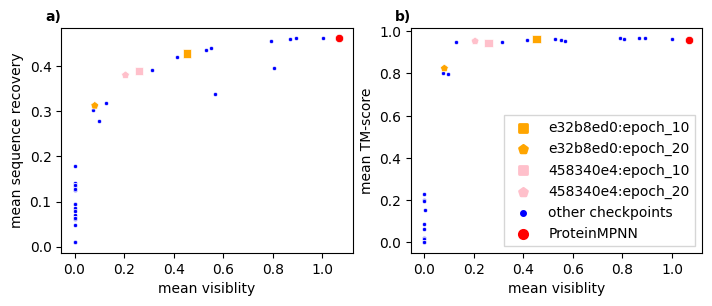

In [61]:
save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_A.pdf") if SAVE_FIGURES else None
plot_trade_off(df_plot, ckpt_ids_selected, save_fig=save_fig)

## Figure 2

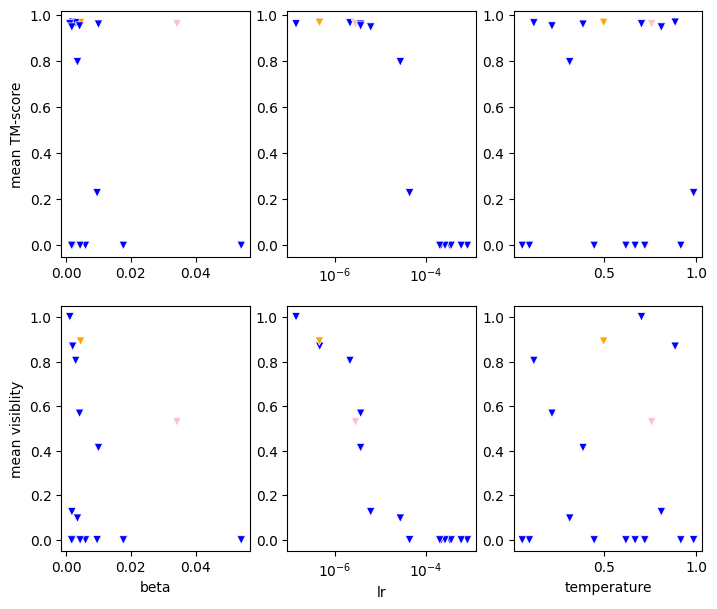

In [62]:
save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_H.pdf") if SAVE_FIGURES else None
plot_hyp_search(df_plot, [('beta', 'linear'), ('lr', 'log'), ('temperature', 'linear')], [2], save_fig=save_fig)

## Figure 3

In [63]:
tm_scores = Design.get_best_tm_scores(best[designed_positions_name])
# vis_mhc_1, vis_mhc_1_abs = Design.get_best_mhc_1_vis(best[designed_positions_name], immuno_setup['mhc_1'], predictor_MHC_I_netmhcpan, None)

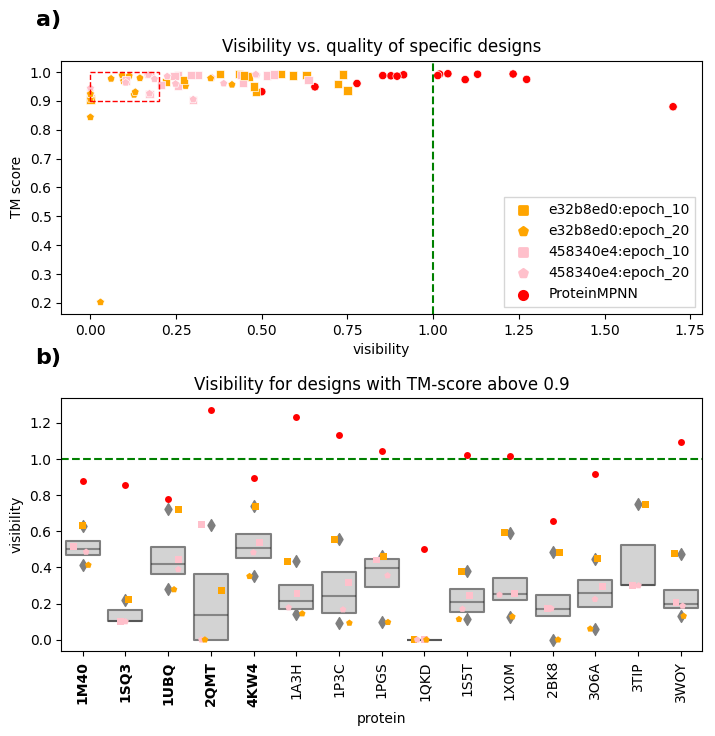

In [64]:
save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_B_{designed_positions_id}.pdf") if SAVE_FIGURES else None

key = (immuno_setup['mhc_1'], predictor_setup['mhc_1'].get_predictor_hash(), None)
_df = plot_specific(
    _source_ids, 
    _protein_ids, #[x for x in _protein_ids if x not in ['5VR2', '1C26']],
    best[designed_positions_name],
    ('vis_mhc_1', 'visibility', False, True, False, key),
    ('tm_scores', 'TM score', False, False, False),
    min_info_y_value=0.9, 
    save_fig=save_fig,
    bold=SPECIFIC_MANUAL
)

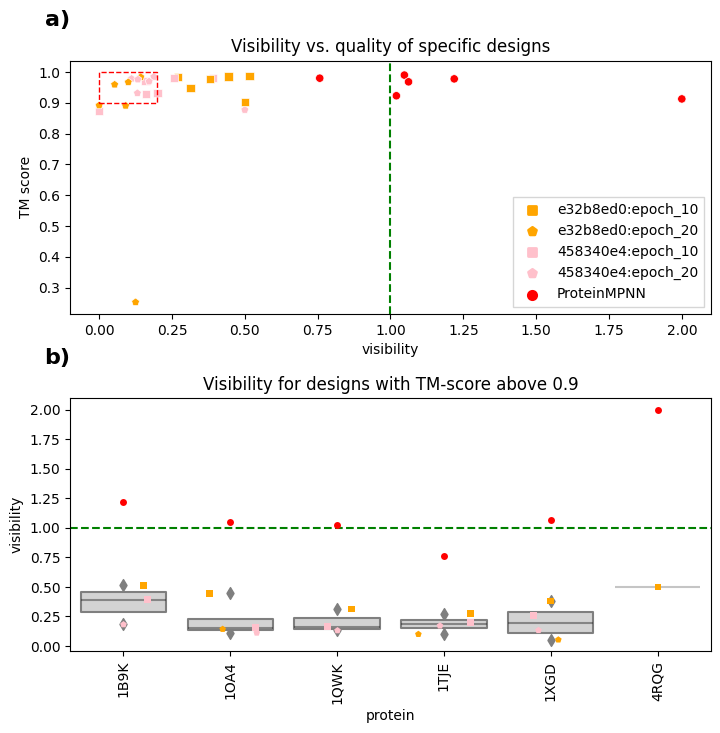

In [65]:
save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_B_{designed_positions_id}_VAL.pdf") if SAVE_FIGURES else None

key = (immuno_setup['mhc_1'], predictor_setup['mhc_1'].get_predictor_hash(), None)
_df = plot_specific(
    _source_ids, 
    specific_proteins[Split.VAL],
    best_val,
    ('vis_mhc_1', 'visibility', False, True, False, key),
    ('tm_scores', 'TM score', False, False, False),
    min_info_y_value=0.9, 
    save_fig=save_fig
)

# Figure 4

[<Axes: ylabel='dssp edit dist'>,
 <Axes: >,
 <Axes: ylabel='$\\Delta$ hydrophobic fitness'>,
 <Axes: ylabel='packing density'>,
 <Axes: ylabel='$\\Delta$ aggrescan3d avg'>,
 <Axes: ylabel='$\\Delta$ aggrescan3d max'>,
 <Axes: ylabel='isoelectric point'>]

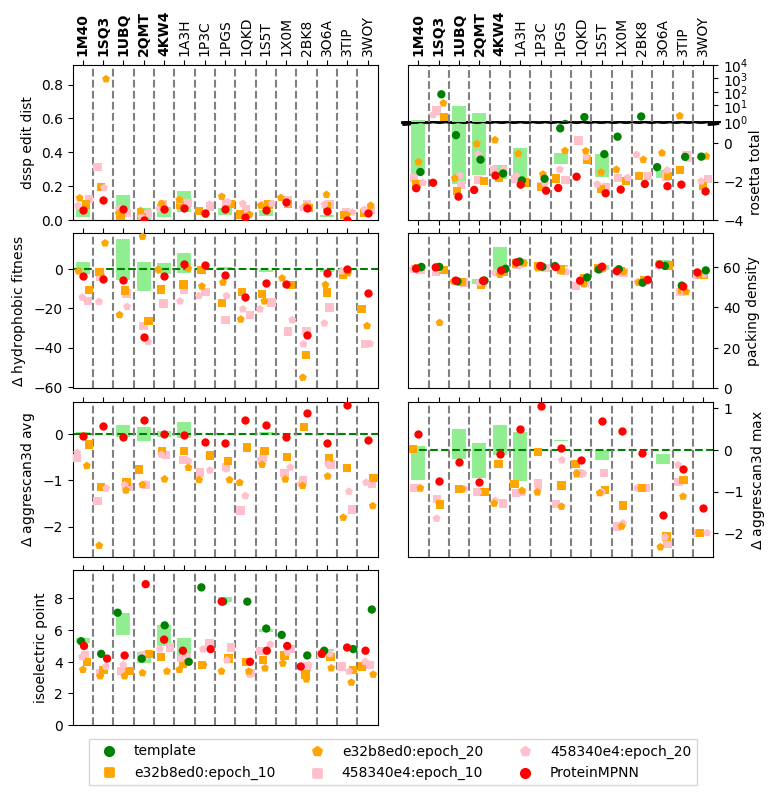

In [66]:
_protein_ids = specific_proteins[Split.TEST]
_source_ids = ckpt_ids_selected + base_model_ids

save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_D_{designed_positions_id}.pdf") if SAVE_FIGURES else None
plot_infos(_source_ids, 
           _protein_ids, 
           best[designed_positions_name], 
           DESTRESS_INFOS_TO_PLOT, 
           show_background_range=SIMILAR_MIN_PROTEINS_CNT,
           save_fig=save_fig, 
           wspace=0.1, hspace=0.1, plot_good=False,
           rename_source_ids=RENAME_SOURCE_IDS,
           bold=SPECIFIC_MANUAL
)

[<Axes: ylabel='dssp edit dist'>,
 <Axes: >,
 <Axes: ylabel='$\\Delta$ hydrophobic fitness'>,
 <Axes: ylabel='packing density'>,
 <Axes: ylabel='$\\Delta$ aggrescan3d avg'>,
 <Axes: ylabel='$\\Delta$ aggrescan3d max'>,
 <Axes: ylabel='isoelectric point'>]

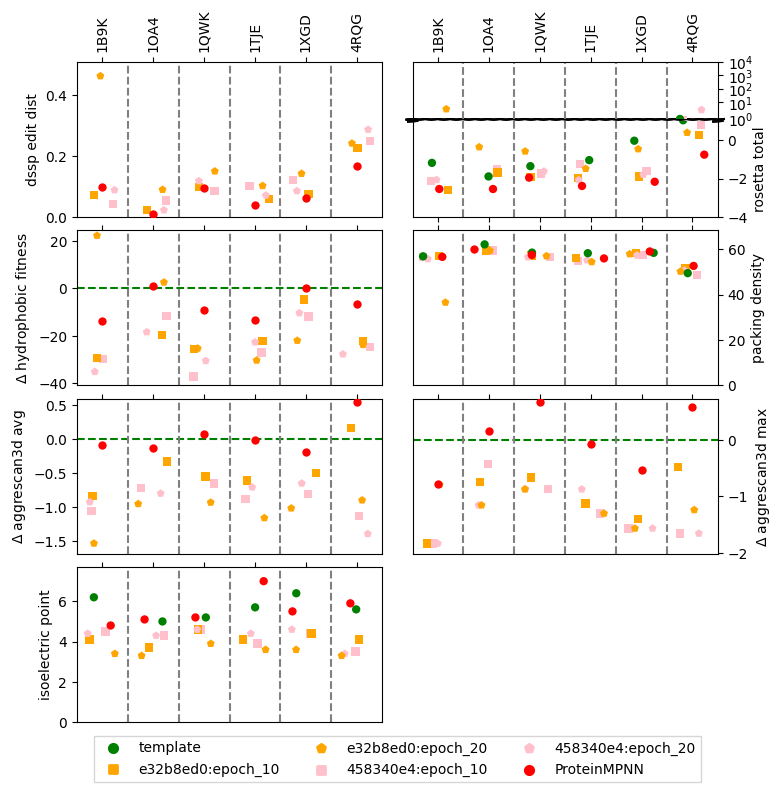

In [67]:
_protein_ids = specific_proteins[Split.VAL]
_source_ids = ckpt_ids_selected + base_model_ids

save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_D_{designed_positions_id}_VAL.pdf") if SAVE_FIGURES else None
plot_infos(_source_ids, 
           _protein_ids, 
           best_val, 
           DESTRESS_INFOS_TO_PLOT, 
           show_background_range=SIMILAR_MIN_PROTEINS_CNT,
           save_fig=save_fig, 
           wspace=0.1, hspace=0.1, plot_good=False,
           rename_source_ids=RENAME_SOURCE_IDS
)

# Figure 5 (and equivalents)

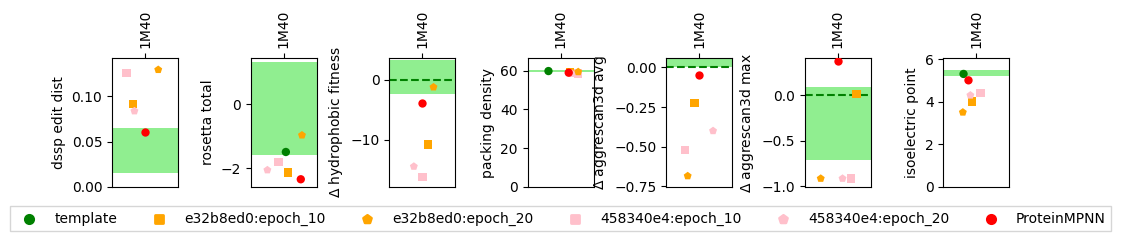

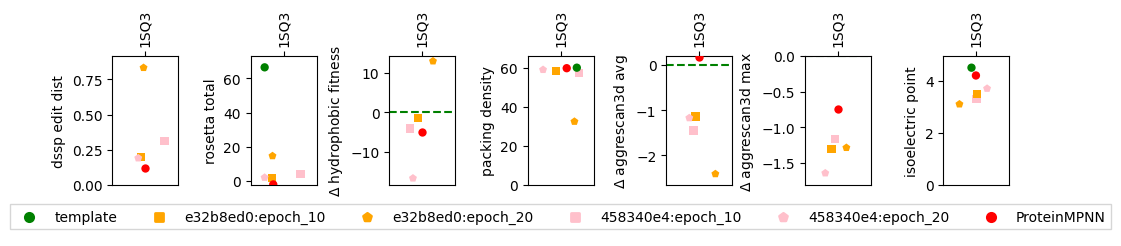

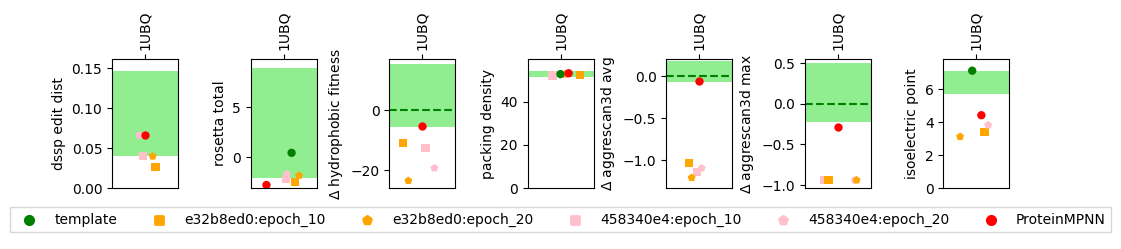

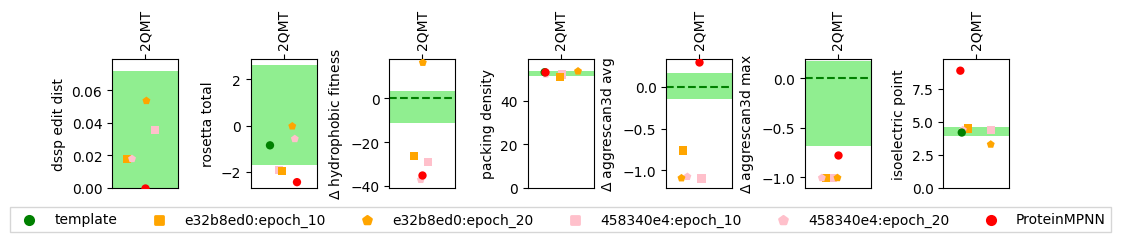

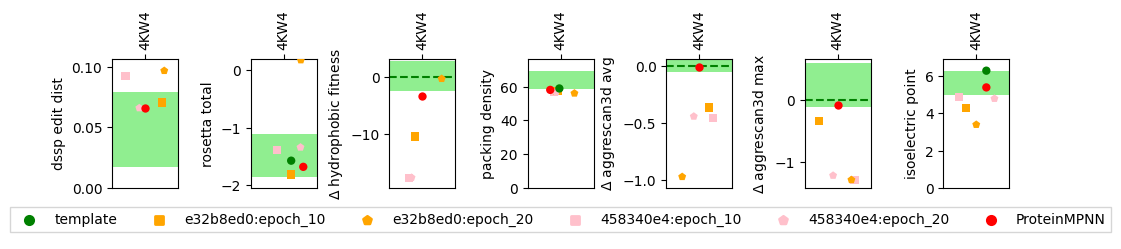

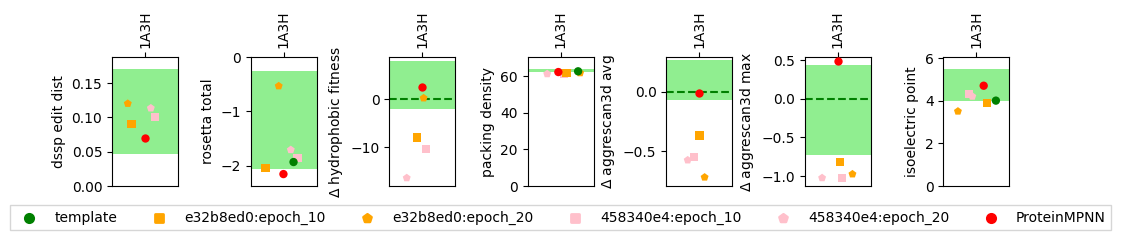

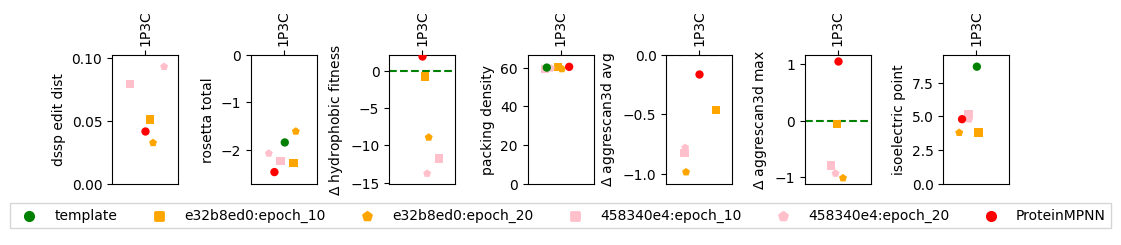

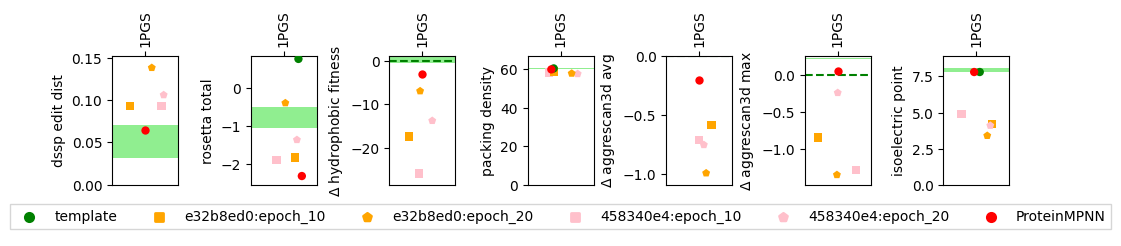

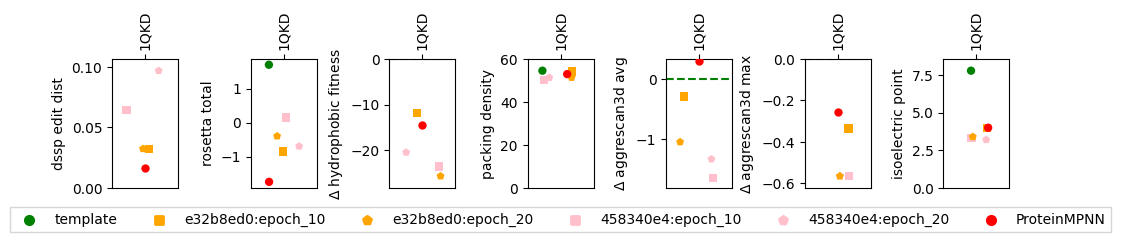

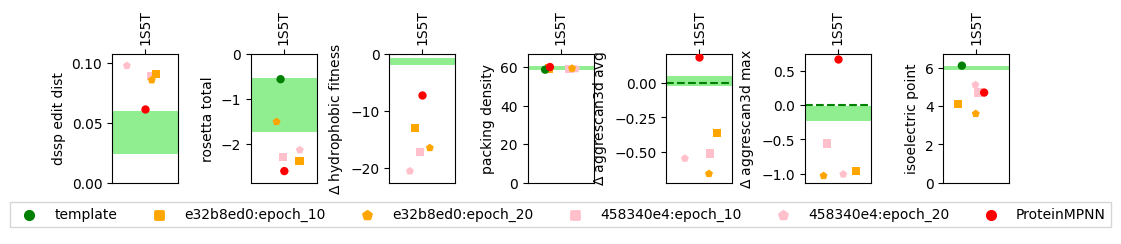

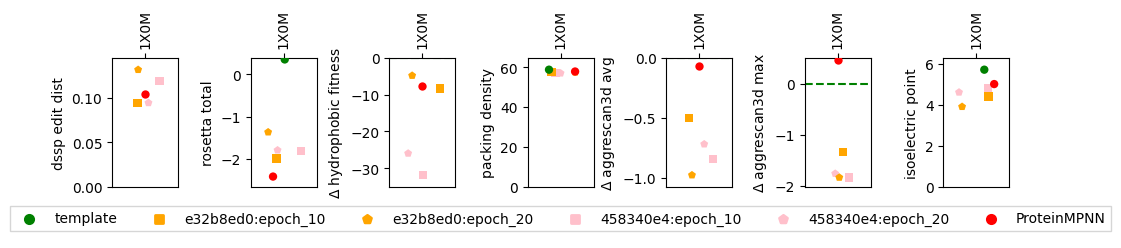

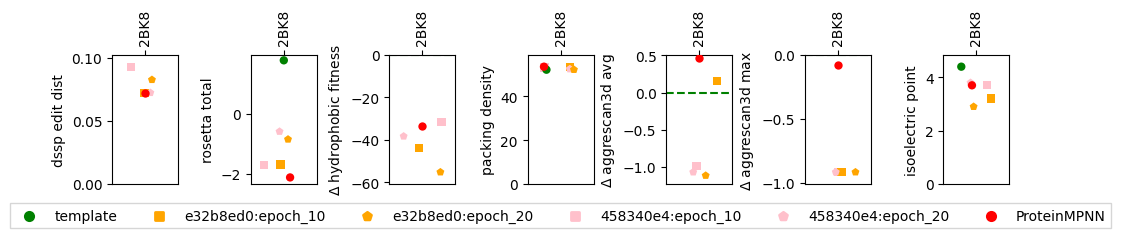

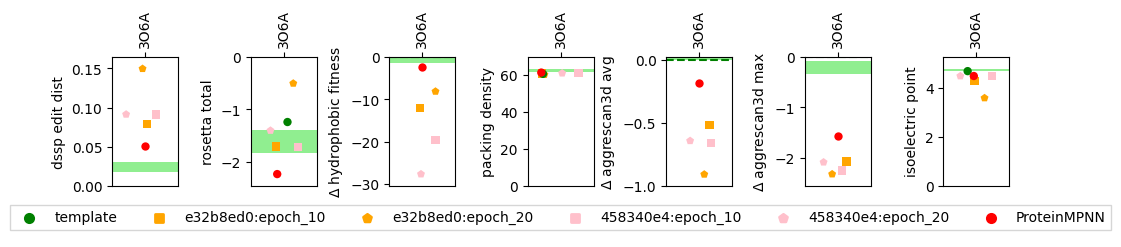

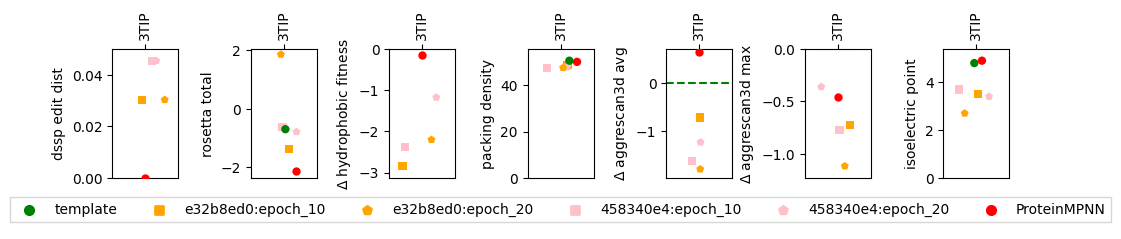

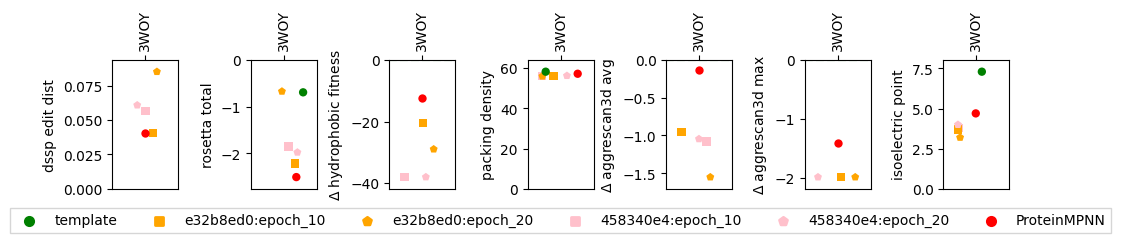

In [68]:
_protein_ids = specific_proteins[Split.TEST]
_source_ids = ckpt_ids_selected + base_model_ids

for protein_id in _protein_ids:
    save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_D_{designed_positions_id}_{protein_id}.pdf") if SAVE_FIGURES else None
    plot_infos(_source_ids, 
               [protein_id], 
               best[designed_positions_name], 
               DESTRESS_INFOS_TO_PLOT, 
               show_background_range=SIMILAR_MIN_PROTEINS_CNT,
               save_fig=save_fig, 
               wspace=1.1, hspace=0.15, plot_good=False, 
               n_cols=len(DESTRESS_INFOS_TO_PLOT), tick_right=False, ignore_ylims=True,
               fig_height=0.2, fig_width=1.4,
               rename_source_ids=RENAME_SOURCE_IDS
    )

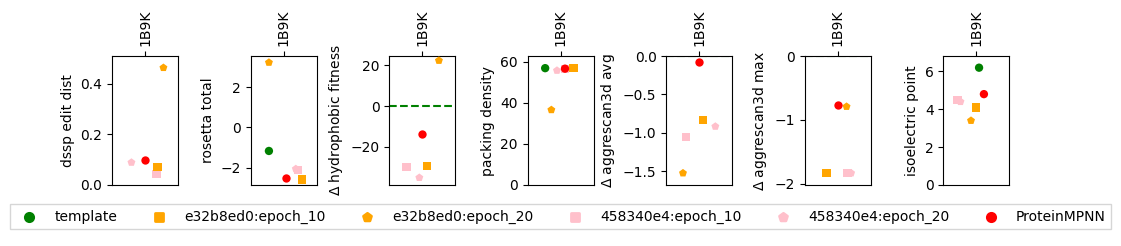

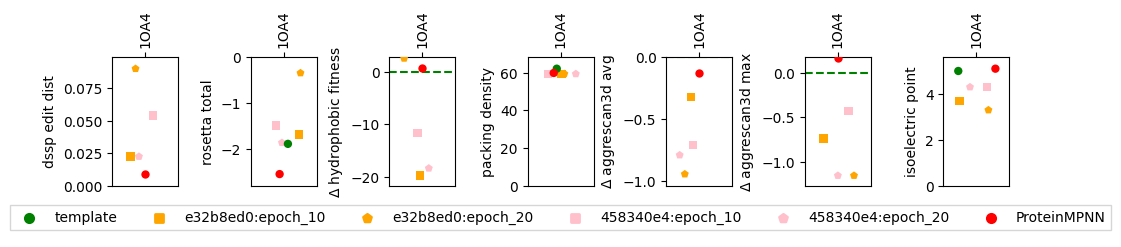

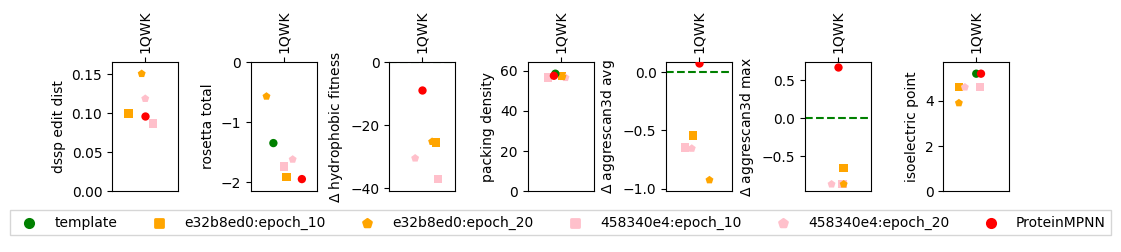

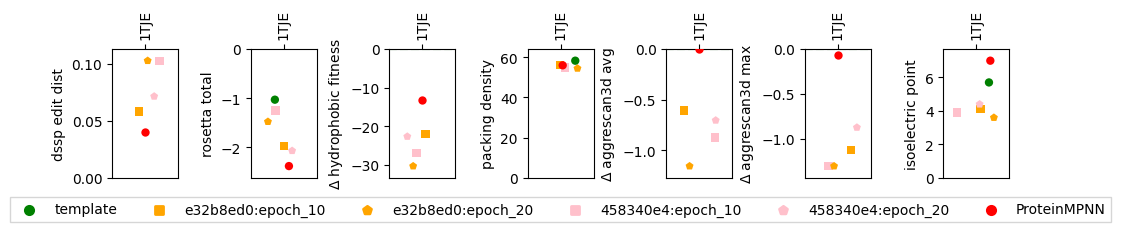

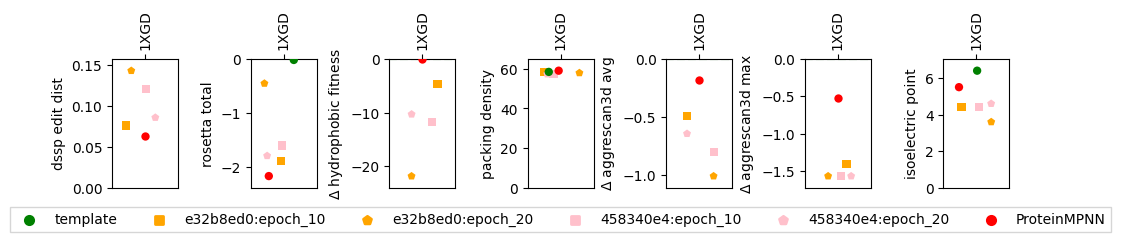

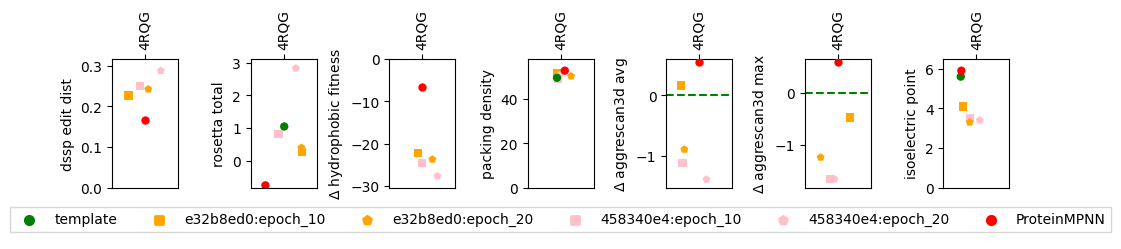

In [69]:
_protein_ids = specific_proteins[Split.VAL]
_source_ids = ckpt_ids_selected + base_model_ids

for protein_id in _protein_ids:
    save_fig = join(G.ENV.ARTEFACTS, "eval", "figures", f"Figure_D_{designed_positions_id}_{protein_id}.pdf") if SAVE_FIGURES else None
    plot_infos(_source_ids, 
               [protein_id], 
               best_val, 
               DESTRESS_INFOS_TO_PLOT, 
               show_background_range=SIMILAR_MIN_PROTEINS_CNT,
               save_fig=save_fig, 
               wspace=1.1, hspace=0.15, plot_good=False, 
               n_cols=len(DESTRESS_INFOS_TO_PLOT), tick_right=False, ignore_ylims=True,
               fig_height=0.2, fig_width=1.4,
               rename_source_ids=RENAME_SOURCE_IDS
    )

# Figure 6 + Box 1 (and equivalents)

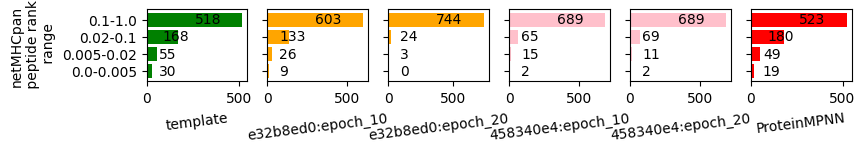

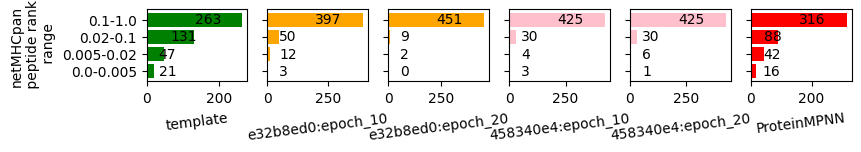

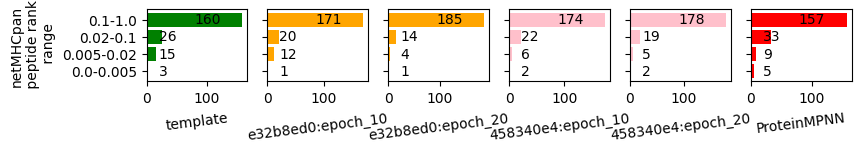

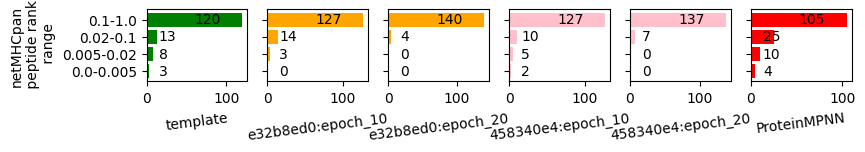

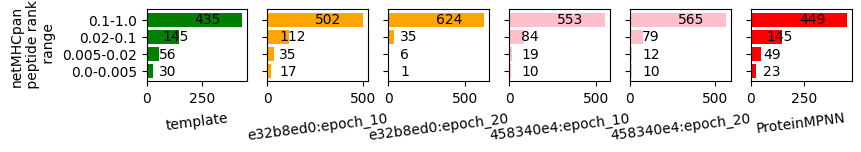

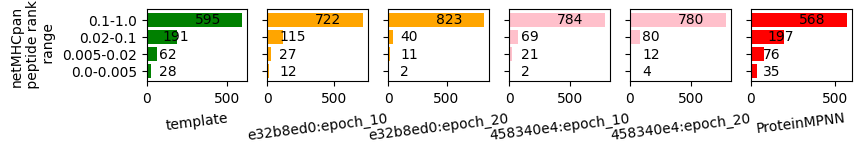

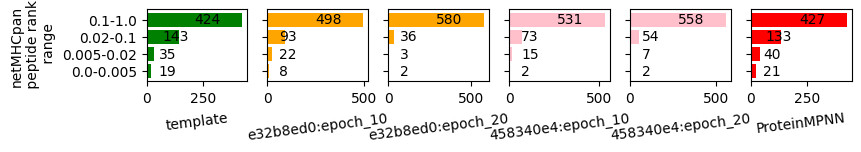

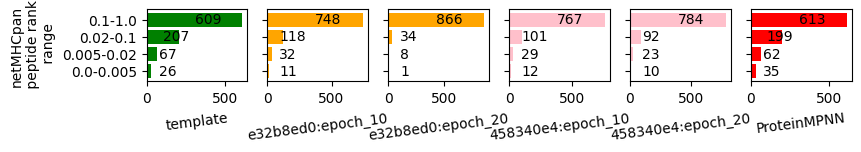

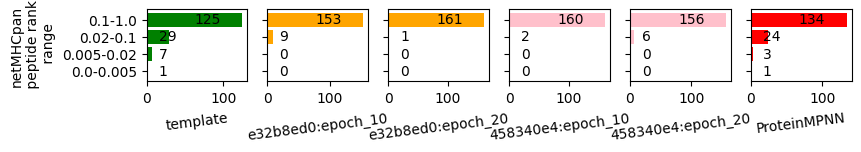

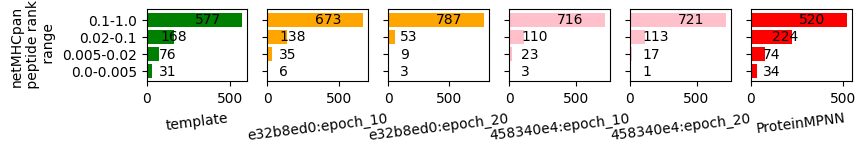

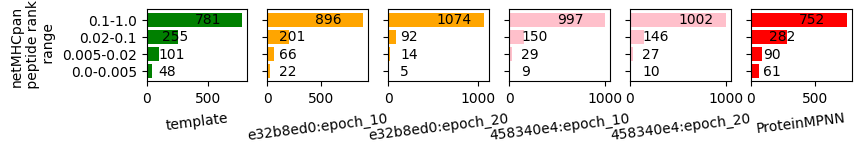

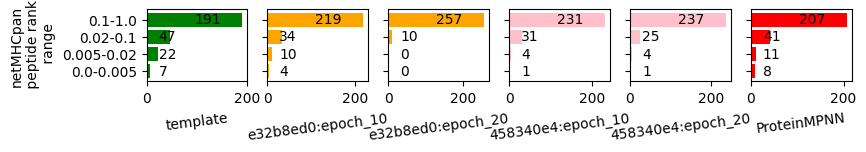

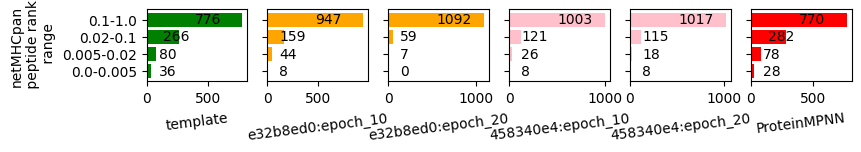

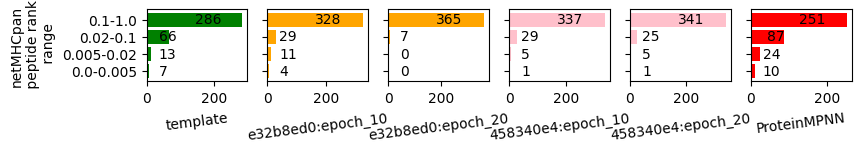

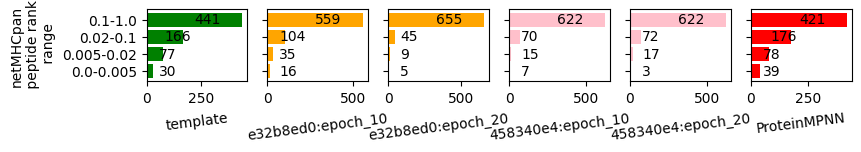

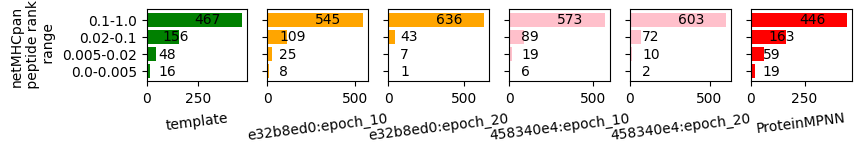

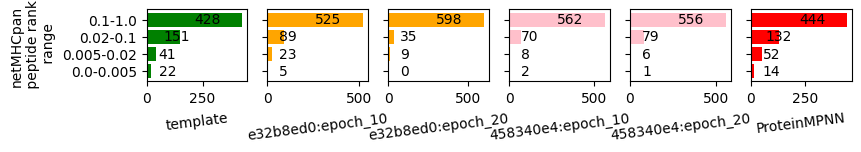

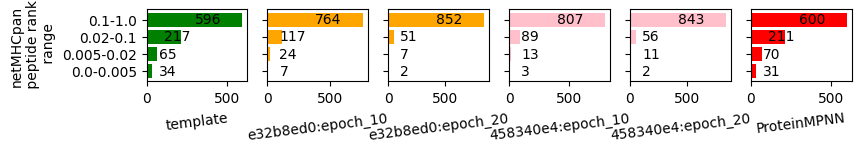

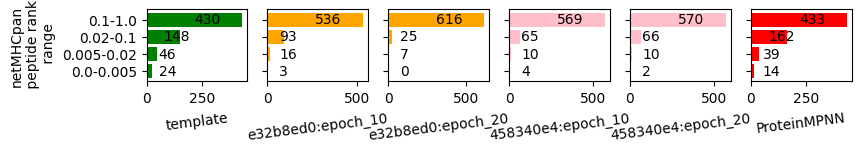

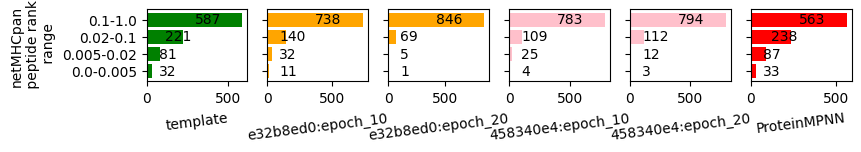

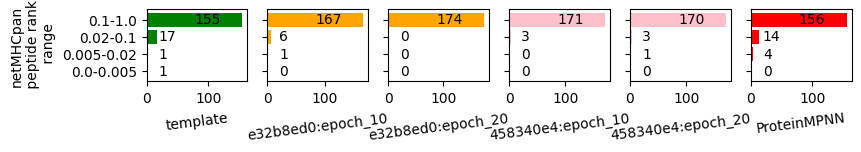

In [70]:
_source_ids = ['data'] + ckpt_ids_selected + base_model_ids

def get_abs_visibility(seq, predictor_setup, immuno_setup):
    presented = predictor_setup['mhc_1'].seq_presented(
        seq,
        immuno_setup['mhc_1']
    )
    presented = set([(p[0], p[3]) for p in presented])
    return len(presented)


for _best, split in [
        (best[designed_positions_name], Split.TEST), 
        (best_val, Split.VAL)
    ]:
    _protein_ids = specific_proteins[split]
    
    for protein_id in _protein_ids:
        #
        # generate the detailed latex pages
        #
        seq_hashes = {}
        seqs = {}
        vis = {}
        latex_sources = ''
        for source_id in _source_ids:
            src_id = source_id.replace(':', '_')
            structure_file_name = f"{src_id}-{protein_id}-{designed_positions_id}.png"
            seq_hashes[source_id] = seq_hash = _best[source_id][protein_id]
            seqs[source_id] = seq = Design.designs[source_id][protein_id].seqs[seq_hash]
            vis[source_id] = get_abs_visibility(seq, predictor_setup, immuno_setup)
    
            tm_score = Design.designs[source_id][protein_id].tm_scores[seq_hash]
            info = None
            
            if source_id != 'data':
                info = " - "
                info += f"TM score: {tm_score:.3f}, "
                info += f"Seq Recovery: {calc_sequence_recovery(seqs['data'], seqs[source_id]):.2f}, "
                info += f"Visibility: {vis[source_id]/vis['data']:.2f}"
                source_id_txt = source_id
            else:
                source_id_txt = 'template'
                
    
    
            latex = r'\noindent \begin{minipage}[c][2.3cm][t]{0.8\textwidth}' + '\n'
            latex += print_seq(seq, name=source_id_txt, latex=True, immuno_setup=immuno_setup, 
                        predictor_setup=predictor_setup, line_breaks=80, info=info, only_first_chain=True)
            latex += '\n'
            latex += r'\end{minipage}' + '\n'
            latex += r"\begin{minipage}[c][2.3cm][c]{0.18\textwidth}"
            latex += (r"\includegraphics[width=1.0\linewidth]{" + structure_file_name + r"}")
            latex += r"\end{minipage}\\" + '\n'
    
            latex_sources += latex + '\n\n'
    
    
        latex_header = r"\subsection{" + protein_id + "}" + '\n'
        latex_header += r"{\centering\includegraphics[width=0.8\linewidth]{Figure_D_all_" + protein_id +  r".pdf}" + '\n'
        latex_header += r"\vspace{-5mm}" + '\n'
        latex_header += r"\captionof{figure}{\textbf{Focus on " + protein_id + r"}}" + '\n'
        latex_header += r"\label{fig:Fig_D_" + protein_id + "}}" + '\n'
        latex_header += r"{\centering\includegraphics[width=0.8\linewidth]{ranks_" + protein_id +  r"-all.pdf}" + '\n'
        latex_header += r"\vspace{-2mm}" + '\n'
        latex_header += r"\captionof{figure}{\textbf{netMHCpan ranks for " + protein_id + r" designs}}" + '\n'
        latex_header += r"\label{fig:ranks_" + protein_id + "}}" + '\n'
        
        latex_final = latex_header + \
            r"\vspace{3mm}" + "\n" + \
            r"\noindent \fbox{\begin{minipage}{1.0\textwidth}" + "\n" + \
            r"{\ttfamily " + '\n' + latex_sources + '\n' + \
            r"}\end{minipage}}\vspace{-3mm}" + '\n' + r"\captionof{Box}{\textbf{Template and designed sequences for " + protein_id + r"}}"
    
    
        str_to_file(latex_final, join(G.ENV.ARTEFACTS, 'eval', 'latex', 'details', f"{protein_id}-{designed_positions_id}.tex" ))
    
        #
        # generate the pymol script
        #
        palette = get_palette(seq_hashes.keys())
        pymol_script = ""
        for source_id, seq_hash in seq_hashes.items():
            src_id = source_id.replace(':', '_')
            pymol_script += "delete all\n"
            pymol_script_load = "# Load the PDB files\n"
            pymol_script_align = "# Align to original structure\n"
            pymol_script_color = "# Color the structures\n"
            pymol_script_settings = "# Set visualization settings (show the structures as cartoons)\n"
            #pymol_script_settings += "show all\n"
            pymol_script_settings += "show cartoon, all\n"
            pymol_script_settings += "bg_color white\n"
            pymol_script_settings += "orient all\n"
            pymol_script_settings += "zoom all\n"
    
            # load data
            pdb_file_path = os.path.join(PDB_DIR_PATH, f"{protein_id}.pdb")
            pymol_script_load += f"load {pdb_file_path}, data \n"
            pymol_script_color += f"color {palette['data']}, data \n"
    
            if protein_id in d_pdb_to_seqs_kwargs:
                assert check_same_sequences('/'.join(pdb_to_seqs(pdb_file_path, **d_pdb_to_seqs_kwargs[protein_id])[0].values()).replace('-', ''), seqs['data'].replace('X', ''))
            else:
                assert check_same_sequences('/'.join(pdb_to_seqs(pdb_file_path)[0].values()).replace('-', ''), seqs['data'].replace('X', ''))
    
            # load and align protein
            if src_id != 'data':
                pdb_file_path = loch.get_pdb_file_path(seq_hash=seq_hash)
                pymol_script_load += f"load {pdb_file_path}, {src_id}\n"
                pymol_script_color += f"color {palette[source_id]}, {src_id}\n"
                assert check_same_sequences('/'.join(pdb_to_seqs(pdb_file_path)[0].values()).replace('-', ''), seqs[source_id].replace('X', ''))
    
                pymol_script_align = f"align {src_id}, data\n"
                    
            pymol_script_load += "remove not resn ALA+ARG+ASN+ASP+CYS+GLN+GLU+GLY+HIS+ILE+LEU+LYS+MET+PHE+PRO+SER+THR+TRP+TYR+VAL\n"
            pymol_script_load += "remove not chain A \n"
            pymol_script_save = "# Save the image as a PNG file\n"
            png_file_path = join(G.ENV.ARTEFACTS, 'eval', 'pymol', 'figures', f'{src_id}-{protein_id}-{designed_positions_id}.png')
            pymol_script_save = f"png {png_file_path}, width=1200, height=800, dpi=300, ray=1\n"
            
            pymol_script += pymol_script_load + pymol_script_align + pymol_script_color + pymol_script_settings + pymol_script_save        
    
        str_to_file(pymol_script, join(G.ENV.ARTEFACTS, 'eval', 'pymol', 'pml', f"{protein_id}-{designed_positions_id}.pml" ))
    
    
        #
        # plot rank plot
        #
        l_seqs = [seqs[src_id] for src_id in _source_ids]
        plot_rank_dist(_source_ids, l_seqs, predictor_setup, immuno_setup, 
                       save_fig=join(G.ENV.ARTEFACTS, 'eval', 'figures', f"ranks_{protein_id}-{designed_positions_id}.pdf"),
                       fig_width=1.1, fig_height=0.08, x_label_rotation=7,
                       rename_source_ids=RENAME_SOURCE_IDS
                      )

    